# Percentile Calculation

For each category where there is anatural ordering and relevant to scoring, a percentile value 0-1 inclusive is assigned.

A tie is handled by assigning the percentile value representing the proportion of values strictly below it. Notably, this gives a percentile value of 0 for all missing entries.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
genderfair = pd.read_csv("gf2025_final.csv")
genderfair.UNITID = genderfair.UNITID.astype(int)
genderfair.columns

Index(['UNITID', 'INSTNM', 'EIN', 'OPEID', 'IALIAS', 'ADDR', 'CITY', 'STABBR',
       'ZIP', 'WEBADDR', 'CSTOTLT', 'EFTOTAL', 'CNTLAFFI', 'STUSRV8',
       'SAINSTM', 'SAINSTW', 'SAOUTLM', 'SAOUTLW', 'AVGSALM', 'AVGSALW',
       'AVGALLM', 'AVGALLW', 'OCCUPCAT', 'HRTOTLT', 'HRTOTLM', 'HRTOTLW',
       'BLKPERC', 'HISPPERC', 'ASIAPERC', 'PRFPERCW_101', 'PRFPERCW_102',
       'PRFPERCW_200', 'BKAAPERCW_101', 'BKAAPERCW_102', 'BKAAPERCW_200',
       'HISPERCW_101', 'HISPERCW_102', 'HISPERCW_200', 'ASIAPERCW_101',
       'ASIAPERCW_102', 'ASIAPERCW_200', 'AVGPERY_HATE', 'PERTHOU_HATE',
       'AVGALL_HATE', 'AVGPERY_VAWA', 'PERTHOU_VAWA', 'AVGALL_VAWA'],
      dtype='object')

In [5]:

# genderfair['ls_1_p'] = genderfair['PERCENTAGE_WOMEN_TRUSTEES'].fillna(-np.inf).rank(pct=True, method='min').fillna(0)
# genderfair['ls_2_p'] = genderfair['PERCENTAGE_WOMEN_KEY_EMPLOYEES'].fillna(-np.inf).rank(pct=True, method='min').fillna(0)
# Note this entry requires inverted sort: low pay for male employees compared to female employees is good.
# genderfair['pp_2_p'] = genderfair['MALE_TO_FEMALE_PAY_RATIO'].fillna(np.inf).rank(pct=True, ascending=False, method='min').fillna(0)
# This one does too: the higher the ratio the lower its percentile.
# genderfair['pp_3_p'] = genderfair['PRESIDENT_TO_AVERAGE_PAY_RATIO'].fillna(-np.inf).rank(pct=True, method='min').fillna(0)


genderfair['ls_3_p'] = genderfair['PRFPERCW_101'].fillna(-np.inf).rank(pct=True, method='min').fillna(0)
genderfair['ls_4_p'] = genderfair['PRFPERCW_102'].fillna(-np.inf).rank(pct=True, method='min').fillna(0)
genderfair['ls_5_p'] = genderfair['PRFPERCW_200'].fillna(-np.inf).rank(pct=True, method='min').fillna(0)
genderfair['pp_4_p'] = (genderfair['AVGSALW'] / genderfair['AVGSALM']).rank(pct=True, method='min').fillna(0)
# In addition to inverted sort, all schools with no violent crime should be placed in the top category. As such the generating method for percentiles is changed to "max"
genderfair['st_hate_p'] = (genderfair['PERTHOU_HATE']).rank(pct=True, ascending=False, method='max').fillna(0)
# Same as above
genderfair['st_vawa_p'] = (genderfair['PERTHOU_VAWA']).rank(pct=True, ascending=False, method='max').fillna(0)



max_black = genderfair['BLKPERC'].mean()
max_hisp = genderfair['HISPPERC'].mean()
max_asia = genderfair['ASIAPERC'].mean()
genderfair['dv_black_p'] = genderfair['BLKPERC'].rank(pct=True, method='min')
genderfair['dv_hisp_p'] = genderfair['HISPPERC'].rank(pct=True, method='min')
genderfair['dv_asia_p'] = genderfair['ASIAPERC'].rank(pct=True, method='min')
genderfair['dv_1_p'] = (genderfair['dv_black_p']*max_black+genderfair['dv_hisp_p']*max_hisp+genderfair['dv_asia_p']*max_asia).rank(pct=True, method='min')



max_black_prof = genderfair['BKAAPERCW_101'].mean()
max_hisp_prof = genderfair['HISPERCW_101'].mean()
max_asia_prof = genderfair['ASIAPERCW_101'].mean()
genderfair['dv_black_prof_p'] = genderfair['BKAAPERCW_101'].rank(pct=True, method='min')
genderfair['dv_hisp_prof_p'] = genderfair['HISPERCW_101'].rank(pct=True, method='min')
genderfair['dv_asia_prof_p'] = genderfair['ASIAPERCW_101'].rank(pct=True, method='min')
genderfair['dv_2_p'] = (genderfair['dv_black_prof_p']*max_black_prof+genderfair['dv_hisp_prof_p']*max_hisp_prof+genderfair['dv_asia_prof_p']*max_asia_prof).rank(pct=True, method='min')



max_black_assc = genderfair['BKAAPERCW_102'].mean()
max_hisp_assc = genderfair['HISPERCW_102'].mean()
max_asia_assc = genderfair['ASIAPERCW_102'].mean()
genderfair['dv_black_assc_p'] = genderfair['BKAAPERCW_102'].rank(pct=True, method='min')
genderfair['dv_hisp_assc_p'] = genderfair['HISPERCW_102'].rank(pct=True, method='min')
genderfair['dv_asia_assc_p'] = genderfair['ASIAPERCW_102'].rank(pct=True, method='min')
genderfair['dv_3_p'] = (genderfair['dv_black_assc_p']*max_black_assc+genderfair['dv_hisp_assc_p']*max_hisp_assc+genderfair['dv_asia_assc_p']*max_asia_assc).rank(pct=True, method='min')



max_black_tenure = genderfair['BKAAPERCW_200'].mean()
max_hisp_tenure = genderfair['HISPERCW_200'].mean()
max_asia_tenure = genderfair['ASIAPERCW_200'].mean()
genderfair['dv_black_tenure_p'] = genderfair['BKAAPERCW_200'].rank(pct=True, method='min')
genderfair['dv_hisp_tenure_p'] = genderfair['HISPERCW_200'].rank(pct=True, method='min')
genderfair['dv_asia_tenure_p'] = genderfair['ASIAPERCW_200'].rank(pct=True, method='min')
genderfair['dv_4_p'] = (genderfair['dv_black_tenure_p']*max_black+genderfair['dv_hisp_tenure_p']*max_hisp+genderfair['dv_asia_tenure_p']*max_asia).rank(pct=True, method='min')

In [6]:
# In here will contain the function which converts percentiles into scores. This does not take into account the effects of any missing values.
def generateScore(percentile, maxScore):
	# return np.round(maxScore*percentile+0.1).astype(int)
	return np.round(maxScore*(-0.5*np.cos(percentile*np.pi)+0.5)).astype(int)

In [7]:
# pp -> Policies & Pay
# ls -> Leadership
# st -> Safety
# dv -> Diversity

# The use of IRS data for scoring is deprecated. The code is kept for legacy purposes.

# genderfair['pp_1a'] = genderfair['CEO_REVIEWED_COMPENSATION'].apply(lambda x: 5 if x == 1 else 0)
# genderfair['pp_1b'] = genderfair['OTHER_REVIEWED_COMPENSATION'].apply(lambda x: 5 if x == 1 else 0)
# genderfair['pp_1'] = genderfair['pp_1a'] + genderfair['pp_1b']
# genderfair['pp_5'] = genderfair['STUSRV8'].apply(lambda x: 10 if x == 1 else 0)
# genderfair['pp_6'] = genderfair['WHISTLEBLOWER_POLICY'].apply(lambda x: 5 if x == 1 else 0)

# genderfair['ls_1'] = generateScore(genderfair['ls_1_p'], 10)
# genderfair['ls_2'] = generateScore(genderfair['ls_2_p'], 10)
# genderfair['ls_3'] = generateScore(genderfair['ls_3_p'], 5)
# genderfair['ls_4'] = generateScore(genderfair['ls_4_p'], 5)
# genderfair['ls_5'] = generateScore(genderfair['ls_5_p'], 5)
# genderfair['pp_2'] = generateScore(genderfair['pp_2_p'], 3)
# genderfair['pp_3'] = generateScore(genderfair['pp_3_p'], 2)
# genderfair['pp_4'] = generateScore(genderfair['pp_4_p'], 5)
# genderfair['st_hate'] = generateScore(genderfair['st_hate_p'], 7)
# genderfair['st_vawa'] = generateScore(genderfair['st_vawa_p'], 7)
# genderfair['dv_1'] = generateScore(genderfair['dv_1_p'], 4)
# genderfair['dv_2'] = generateScore(genderfair['dv_2_p'], 4)
# genderfair['dv_3'] = generateScore(genderfair['dv_3_p'], 4)
# genderfair['dv_4'] = generateScore(genderfair['dv_4_p'], 4)

In [8]:
genderfair['pp_5'] = genderfair['STUSRV8'].apply(lambda x: 10 if x == 1 else 0)

genderfair['ls_3'] = generateScore(genderfair['ls_3_p'], 10)
genderfair['ls_4'] = generateScore(genderfair['ls_4_p'], 10)
genderfair['ls_5'] = generateScore(genderfair['ls_5_p'], 10)
genderfair['pp_4'] = generateScore(genderfair['pp_4_p'], 15)
genderfair['st_hate'] = generateScore(genderfair['st_hate_p'], 10)
genderfair['st_vawa'] = generateScore(genderfair['st_vawa_p'], 10)
genderfair['dv_1'] = generateScore(genderfair['dv_1_p'], 5)
genderfair['dv_2'] = generateScore(genderfair['dv_2_p'], 10)
genderfair['dv_3'] = generateScore(genderfair['dv_3_p'], 5)
genderfair['dv_4'] = generateScore(genderfair['dv_4_p'], 5)

In [9]:
# pp -> Policies & Pay
# ls -> Leadership
# st -> Safety
# dv -> Diversity

genderfair['pp_no_irs'] = genderfair['pp_4'] + genderfair['pp_5']
genderfair['ls_no_irs'] = genderfair['ls_3'] + genderfair['ls_4'] + genderfair['ls_5']
genderfair['st_no_irs'] = genderfair['st_hate'] + genderfair['st_vawa']
genderfair['dv_no_irs'] = genderfair['dv_1'] + genderfair['dv_2'] + genderfair['dv_3'] + genderfair['dv_4']

genderfair[['UNITID','INSTNM','pp_no_irs','ls_no_irs','st_no_irs','dv_no_irs']].head(20)

,UNITID,INSTNM,pp_no_irs,ls_no_irs,st_no_irs,dv_no_irs
0,100654,Alabama A & M University,13,4,10,17
1,100663,University of Alabama at Birmingham,3,10,1,23
2,100706,University of Alabama in Huntsville,10,3,6,20
3,100724,Alabama State University,4,19,10,18
4,100751,The University of Alabama,10,8,4,21
5,100760,Central Alabama Community College,13,9,14,4
6,100812,Athens State University,13,28,20,16
7,100830,Auburn University at Montgomery,10,9,0,14
8,100858,Auburn University,0,7,2,22
9,100937,Birmingham-Southern College,0,16,12,2


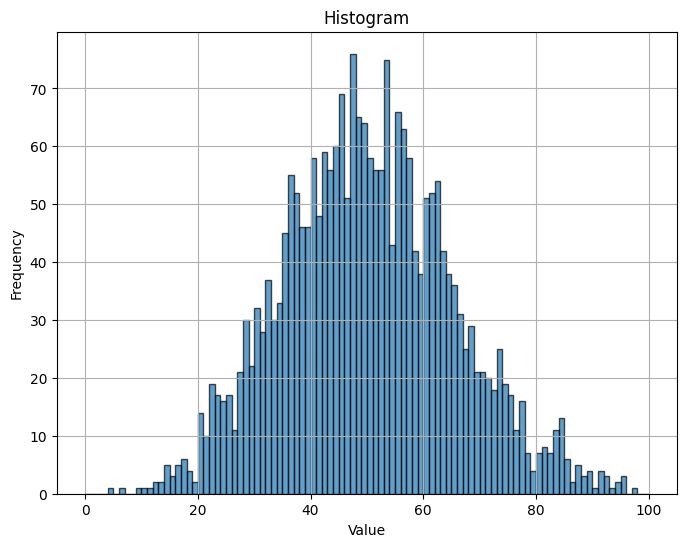

In [10]:
plt.figure(figsize=(8, 6))
plt.hist(genderfair["pp_no_irs"]+genderfair["ls_no_irs"]+genderfair["st_no_irs"]+genderfair["dv_no_irs"], bins=range(101), edgecolor='black', alpha=0.7)
plt.title('Histogram')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [11]:
genderfair[['UNITID','INSTNM','pp_no_irs','ls_no_irs','st_no_irs','dv_no_irs']].to_csv(path_or_buf='gf2025_scores.csv', index=False)

In [14]:
dbName = "PublicFacingData"
tableName = "SchoolScores"
initial = f"INSERT INTO `{dbName}`.`{tableName}` (`UNITID`,`INSTNM`,`STABBR`,`POLICIES`,`LEADERSHIP`,`SAFETY`,`DIVERSITY`) VALUES"
statements = genderfair.apply(lambda row: f"({row['UNITID']}, \"{row['INSTNM']}\", \"{row['STABBR']}\", {row['pp_no_irs']}, {row['ls_no_irs']}, {row['st_no_irs']}, {row['dv_no_irs']}),", axis=1)
end = ";"

In [15]:
# Side effect of this script: after every (value), MySQL requires that there be a ',' except the very last line which is followed by a ';'. Please go into the text file and remove that last ',' otherwise the script will throw an error.

with open('score_insert_statements', 'w') as f:
	f.write(f"{initial}\n")
	for line in statements:
		f.write(f"{line}\n")
	f.write(f"{end}\n")